In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


To determine the predictive power of our features, we calculate their Pearson correlation with the target variable (Personality). Features with strong positive or negative correlations are high-value predictors. Features with correlations near zero may be considered for removal to prevent model noise.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import os
import pandas as pd


os.chdir('/content/drive/MyDrive/AI_ML_Project_dataset')


print(os.listdir())

['personality_dataset.csv', 'dataset_cleaned.csv']


In [5]:
df = pd.read_csv('dataset_cleaned.csv')


print("Loaded shape:", df.shape)
df.head()

Loaded shape: (2900, 8)


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0.0,4.0,6.0,0.0,13.0,5.0,1
1,9.0,1.0,0.0,0.0,1.0,0.0,3.0,0
2,9.0,1.0,1.0,2.0,1.0,5.0,2.0,0
3,0.0,0.0,6.0,7.0,0.0,14.0,8.0,1
4,3.0,0.0,9.0,4.0,0.0,8.0,5.0,1


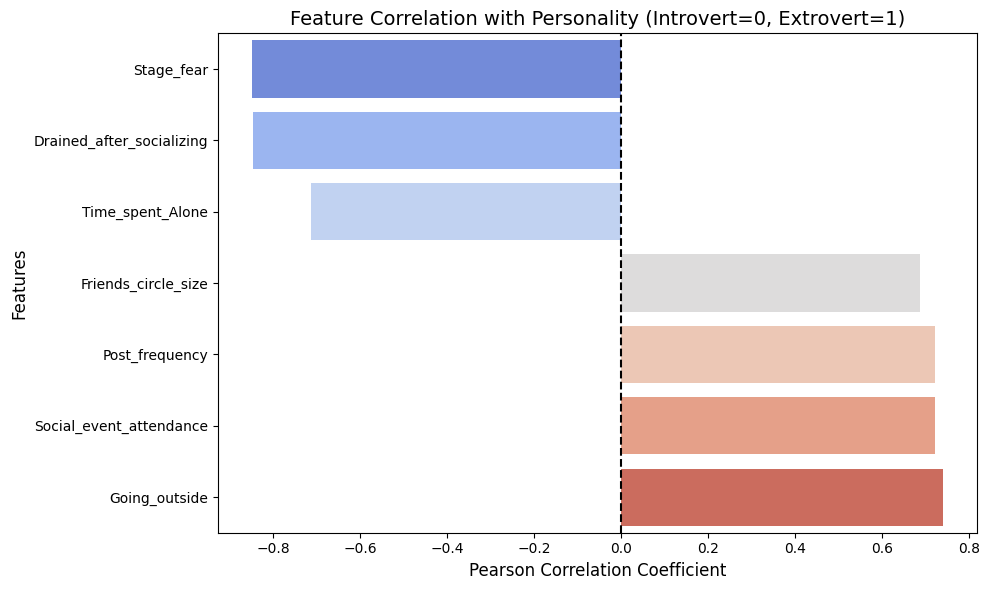

--- Correlation Scores ---
Stage_fear                  -0.847467
Drained_after_socializing   -0.845388
Time_spent_Alone            -0.712467
Friends_circle_size          0.686321
Post_frequency               0.720817
Social_event_attendance      0.721568
Going_outside                0.739251
Name: Personality, dtype: float64


In [9]:

corr_with_target = df.corr()['Personality'].drop('Personality').sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, hue=corr_with_target.index, palette='coolwarm', legend=False)
plt.title('Feature Correlation with Personality (Introvert=0, Extrovert=1)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Add a line at zero
plt.tight_layout()
plt.show()

# 3. Print the exact numbers
print("--- Correlation Scores ---")
print(corr_with_target)

Stage_fear (~-0.85) & Drained_after_socializing (~-0.84): These two are your absolute strongest predictors. If someone answers "Yes" (1) to having stage fear or feeling drained, the model will almost certainly predict they are an Introvert (0).

Going_outside (~0.74) & Social_event_attendance (~0.72): As these behaviors increase, the model heavily leans toward Extrovert (1).

CONCLUSION: Because every feature exhibits a high absolute correlation (>0.65) with the target variable, there are no "noisy" or weak features. All columns will be retained for the model training phase.